# **Capítulo 1: Fundamentos del Procesamiento Digital de Señales y Filtros Digitales**

```
 Libro:  Procesamiento Digital de Voz e Imágenes en la Era de la Inteligencia Artificial
```


**Autor:  Dora María Ballesteros Larrotta**  
Universidad Militar Nueva Granada (UMNG)

---

### Material complementario del libro

Este notebook acompaña el **Capítulo 1** y contiene los ejemplos desarrollados a lo largo del texto. Se recomienda seguir el mismo orden del libro para obtener el máximo provecho de las actividades propuestas.

---

# **Ejemplo 1.  Señal discreta en Python de duración finita**

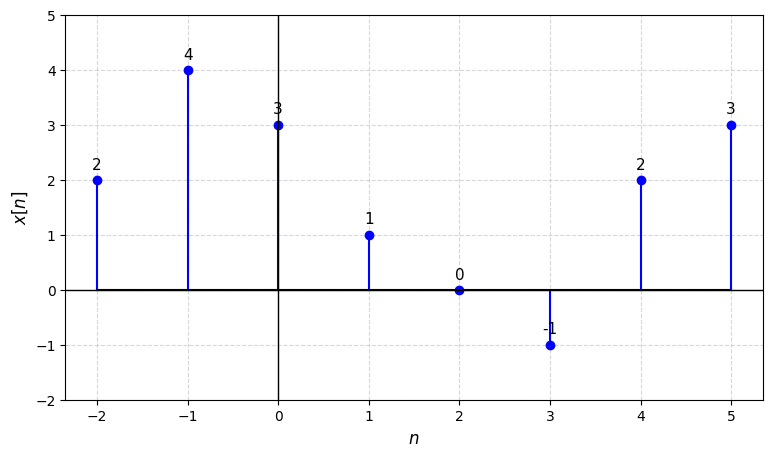

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Definición de la señal discreta
n = np.array([-2, -1, 0, 1, 2, 3, 4, 5])
x = np.array([2, 4, 3, 1, 0, -1, 2, 3])

# Gráfica tipo stem
plt.figure(figsize=(9, 5))

plt.stem(n, x, basefmt="k-", linefmt="b-", markerfmt="bo")

# Ejes
plt.axhline(0, color="black", linewidth=1)
plt.axvline(0, color="black", linewidth=1)

# Etiquetas
plt.xlabel(r"$n$", fontsize=12)
plt.ylabel(r"$x[n]$", fontsize=12)

# Marcas de los ejes
plt.xticks(n)
plt.yticks(np.arange(-2, 6, 1))

# Cuadrícula
plt.grid(True, linestyle="--", alpha=0.5)

# Valores sobre cada muestra
for ni, xi in zip(n, x):
    plt.text(ni, xi + 0.2, str(xi), ha="center", fontsize=11)

plt.show()

# **Ejemplo 3. Polos y ceros a partir de la función de transferencia**

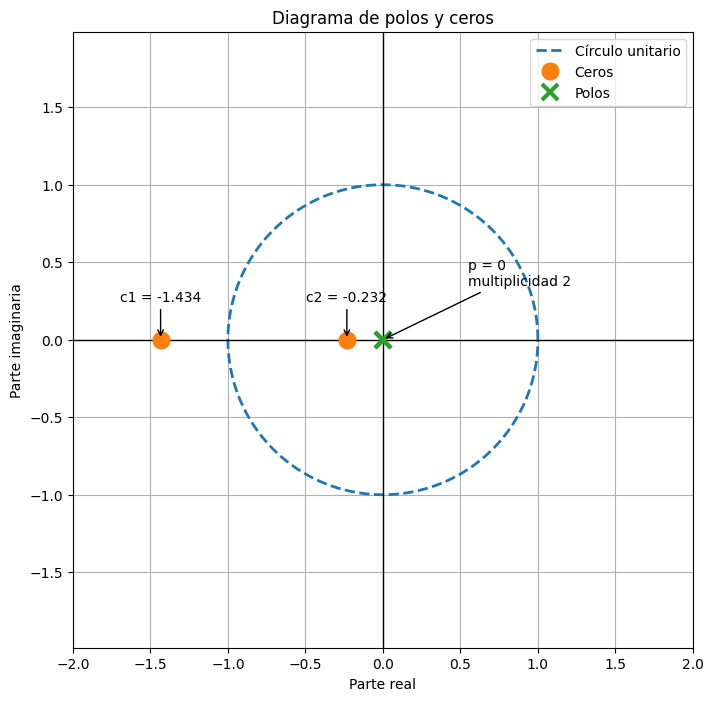

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# H(z) = (3z² + 5z + 1)/(9z²)
num = [3, 5, 1]
den = [9, 0, 0]

zeros = np.roots(num)
poles = np.roots(den)
theta = np.linspace(0, 2*np.pi, 500)
plt.figure(figsize=(8, 8))

# Círculo unitario
plt.plot(np.cos(theta), np.sin(theta), '--', linewidth=2,
         label='Círculo unitario')
# Ejes
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)

# Ceros: ahora rellenos para que se vean
plt.plot(np.real(zeros), np.imag(zeros),'o', markersize=12, label='Ceros')

# Polos
plt.plot(np.real(poles), np.imag(poles),
         'x', markersize=12, markeredgewidth=3, label='Polos')

# Etiquetas de ceros
for i, z in enumerate(zeros, start=1):
    plt.annotate(f'c{i} = {np.real(z):.3f}',
                 xy=(np.real(z), np.imag(z)),
                 xytext=(np.real(z), 0.25),
                 arrowprops=dict(arrowstyle='->'),
                 ha='center')

# Etiqueta única del polo doble
plt.annotate('p = 0\nmultiplicidad 2',
             xy=(0, 0),
             xytext=(0.55, 0.35),
             arrowprops=dict(arrowstyle='->'))

plt.xlabel('Parte real'); plt.ylabel('Parte imaginaria')
plt.title('Diagrama de polos y ceros')

plt.grid(True); plt.axis('equal'); plt.xlim(-2, 2)
plt.ylim(-2, 2); plt.legend(); plt.show()

# **Ejemplo 4.  Respuesta en frecuencia filtro de promedio**

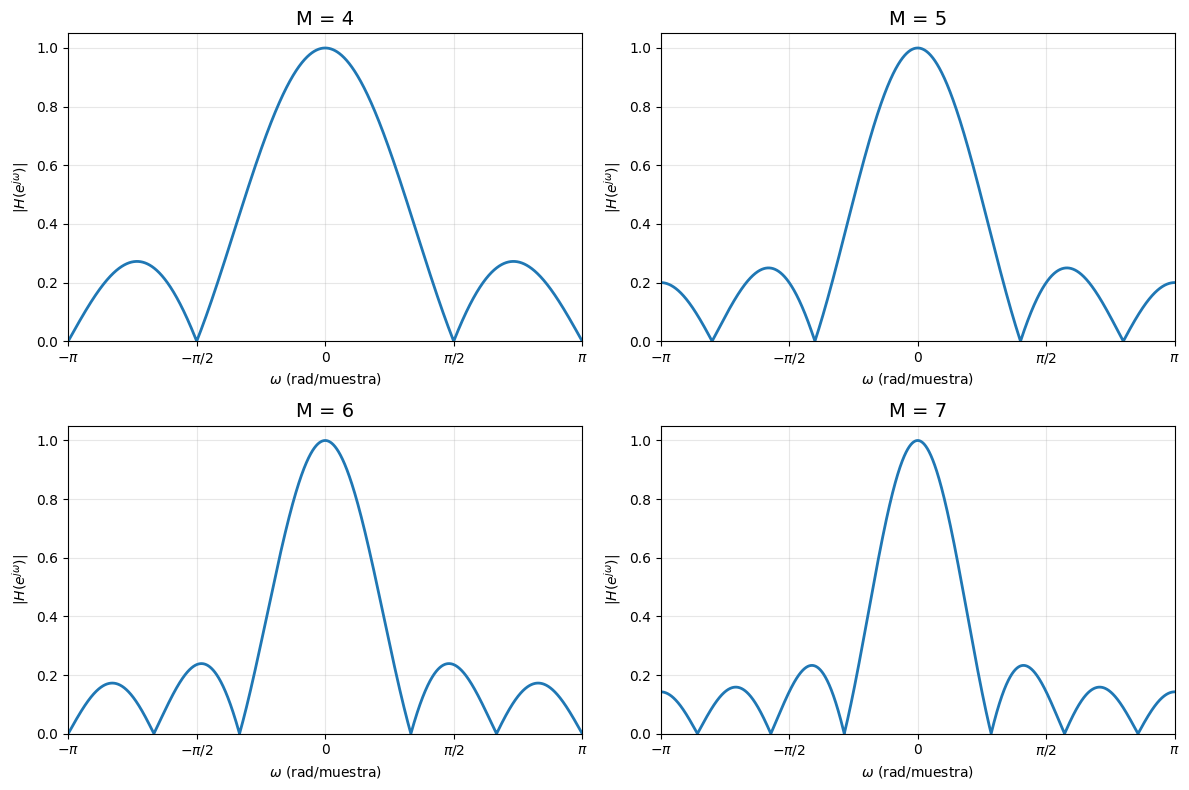

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Valores de M
M_values = [4, 5, 6, 7]

# Frecuencia digital entre -pi y pi
omega = np.linspace(-np.pi, np.pi, 4000)

plt.figure(figsize=(12, 8))

for i, M in enumerate(M_values, 1):

    # Respuesta en frecuencia
    H = np.zeros_like(omega, dtype=complex)

    for n in range(M):
        H += np.exp(-1j * omega * n)
    H = H / M

    # Magnitud lineal
    H_mag = np.abs(H)

    plt.subplot(2, 2, i); plt.plot(omega, H_mag, linewidth=2)

    plt.title(f"M = {M}", fontsize=14); plt.xlabel(r'$\omega$ (rad/muestra)')
    plt.ylabel(r'$|H(e^{j\omega})|$'); plt.xlim([-np.pi, np.pi]); plt.ylim([0, 1.05])
    plt.grid(True, alpha=0.3)

    plt.xticks(
        [-np.pi, -np.pi/2, 0, np.pi/2, np.pi],
        [r'$-\pi$', r'$-\pi/2$', '0', r'$\pi/2$', r'$\pi$']
    )

plt.tight_layout()
plt.show()

# **Ejemplo 5.  Diseño de filtro FIR por método de ventaneo, apoyado en Python**

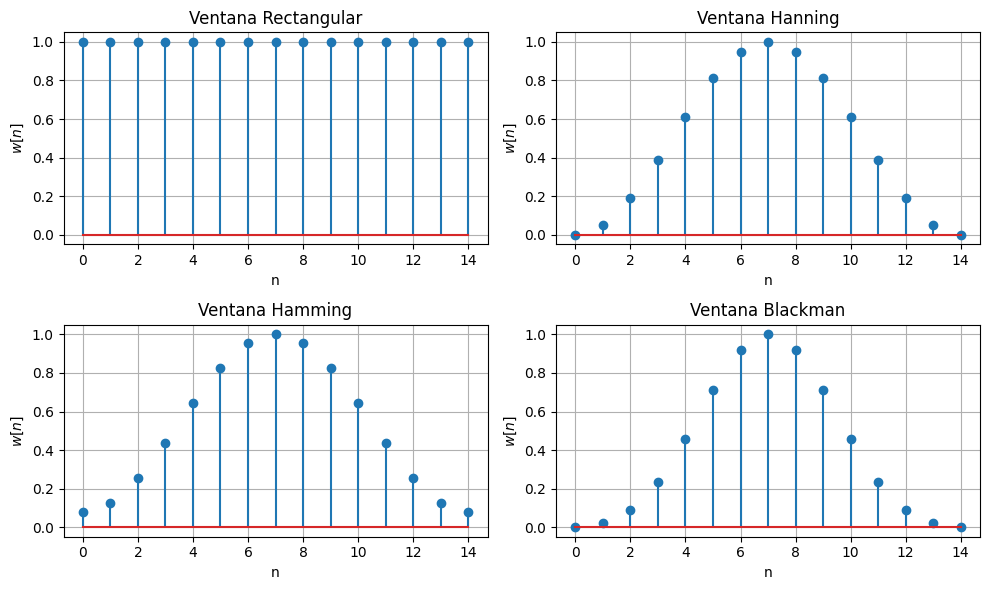

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Longitud de la ventana
M = 15
n = np.arange(M)

# Ventanas
w_rect = np.ones(M)
w_hann = np.hanning(M)
w_hamm = np.hamming(M)
w_black = np.blackman(M)

# Figura 2x2
fig, ax = plt.subplots(2, 2, figsize=(10, 6))

# Rectangular
ax[0,0].stem(n, w_rect); ax[0,0].set_title('Ventana Rectangular')
ax[0,0].set_xlabel('n'); ax[0,0].set_ylabel(r'$w[n]$')
ax[0,0].grid(True)

# Hanning
ax[0,1].stem(n, w_hann); ax[0,1].set_title('Ventana Hanning')
ax[0,1].set_xlabel('n'); ax[0,1].set_ylabel(r'$w[n]$')
ax[0,1].grid(True)

# Hamming
ax[1,0].stem(n, w_hamm); ax[1,0].set_title('Ventana Hamming')
ax[1,0].set_xlabel('n'); ax[1,0].set_ylabel(r'$w[n]$')
ax[1,0].grid(True)

# Blackman
ax[1,1].stem(n, w_black); ax[1,1].set_title('Ventana Blackman')
ax[1,1].set_xlabel('n'); ax[1,1].set_ylabel(r'$w[n]$')
ax[1,1].grid(True)

plt.tight_layout(); plt.show()

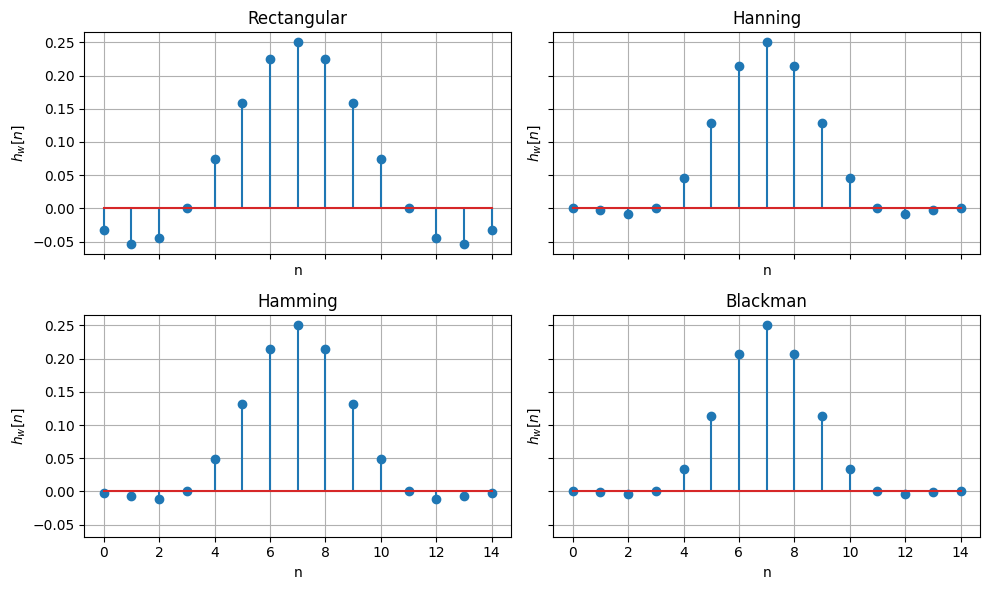

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


M = 15 # longitud de la ventana
wc = np.pi / 4 # frecuencia de corte en el rango [0 pi]
n = np.arange(M) # indices
alpha = (M - 1) / 2 # centro de simetría

# Respuesta al impulso ideal (pasa-bajo)
hd = np.zeros(M)

for i in range(M):
    if n[i] == alpha:
        hd[i] = wc / np.pi
    else:
        hd[i] = np.sin(wc * (n[i] - alpha)) / \
                (np.pi * (n[i] - alpha))
# Ventanas
w_rect = np.ones(M)
w_hann = np.hanning(M)
w_hamm = np.hamming(M)
w_black = np.blackman(M)

# Respuestas al impulso del filtro ideal, multiplicado por las ventanas
hw_rect = hd * w_rect
hw_hann = hd * w_hann
hw_hamm = hd * w_hamm
hw_black = hd * w_black

# Gráficas
fig, ax = plt.subplots(2, 2, figsize=(10, 6),
                       sharex=True, sharey=True)

ventanas = [hw_rect, hw_hann, hw_hamm, hw_black]
titulos = ['Rectangular', 'Hanning','Hamming','Blackman']

for eje, hw, titulo in zip(ax.ravel(), ventanas, titulos):

    eje.stem(n, hw); eje.set_title(titulo)
    eje.set_xlabel('n'); eje.set_ylabel(r'$h_w[n]$')
    eje.grid(True)

plt.tight_layout()
plt.show()

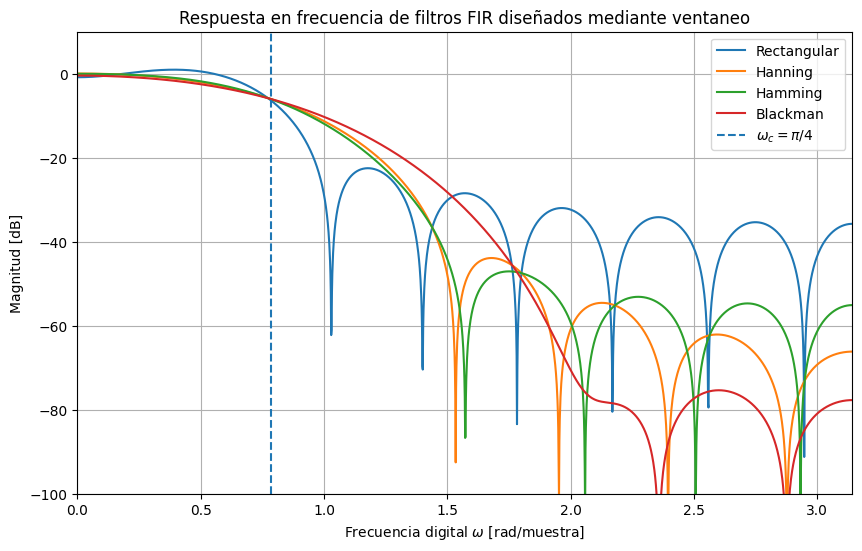

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import freqz

# Respuestas en frecuencia
omega, H_rect = freqz(hw_rect, worN=2048)
_, H_hann = freqz(hw_hann, worN=2048)
_, H_hamm = freqz(hw_hamm, worN=2048)
_, H_black = freqz(hw_black, worN=2048)

# Gráfica comparativa
plt.figure(figsize=(10,6))

plt.plot(omega, 20*np.log10(np.abs(H_rect)+1e-10),
         label='Rectangular')

plt.plot(omega, 20*np.log10(np.abs(H_hann)+1e-10),
         label='Hanning')

plt.plot(omega, 20*np.log10(np.abs(H_hamm)+1e-10),
         label='Hamming')

plt.plot(omega, 20*np.log10(np.abs(H_black)+1e-10),
         label='Blackman')

plt.axvline(wc,
            linestyle='--',
            label=r'$\omega_c=\pi/4$')

plt.xlim([0, np.pi])
plt.ylim([-100, 10])

plt.xlabel(r'Frecuencia digital $\omega$ [rad/muestra]')
plt.ylabel('Magnitud [dB]')
plt.title('Respuesta en frecuencia de filtros FIR diseñados mediante ventaneo')
plt.grid(True)
plt.legend()

plt.show()

# **Ejemplo 6.  Efecto de la longitud de la ventana**

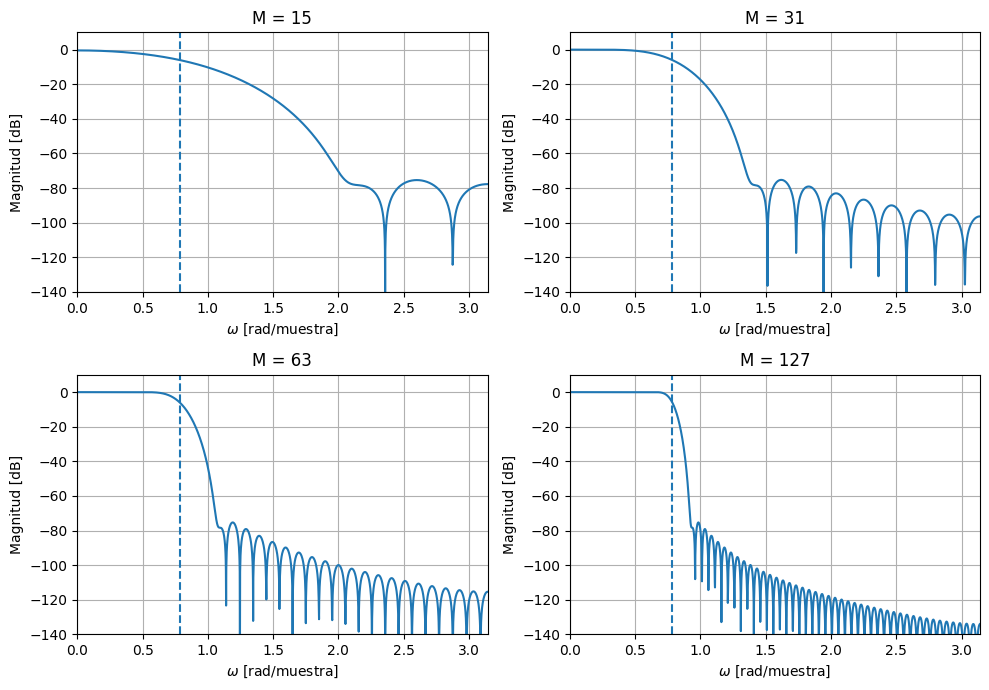

M=127
|H(wc)| = -6.02 dB


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import freqz

wc = np.pi / 4 # Frecuencia de corte
M_values = [15, 31, 63, 127] # Valores de M
fig, ax = plt.subplots(2, 2, figsize=(10, 7))

for eje, M in zip(ax.ravel(), M_values):
    n = np.arange(M)
    alpha = (M - 1) / 2
    # Respuesta al impulso ideal
    hd = np.zeros(M)

    for i in range(M):
        if n[i] == alpha:
            hd[i] = wc / np.pi
        else:
            hd[i] = np.sin(wc * (n[i] - alpha)) / \
                    (np.pi * (n[i] - alpha))

    w = np.blackman(M) # Ventana Blackman
    hw = hd * w  # Respuesta al impulso ventaneada
    omega, H = freqz(hw, worN=2048) # Respuesta en frecuencia

    eje.plot(omega, 20 * np.log10(np.abs(H) + 1e-10))
    eje.axvline(wc, linestyle='--')
    eje.set_title(f'M = {M}'); eje.set_xlabel(r'$\omega$ [rad/muestra]')
    eje.set_ylabel('Magnitud [dB]'); eje.set_xlim([0, np.pi])
    eje.set_ylim([-140, 10]); eje.grid(True)

plt.tight_layout()
plt.show()

idx = np.argmin(np.abs(omega - wc))

print(f"M={M}")
print(f"|H(wc)| = {20*np.log10(np.abs(H[idx])):.2f} dB")

# **Ejemplo 7.  Diseño de filtro Butterworth pasa-bajo mediante Transformada Bilineal, apoyado en Python**

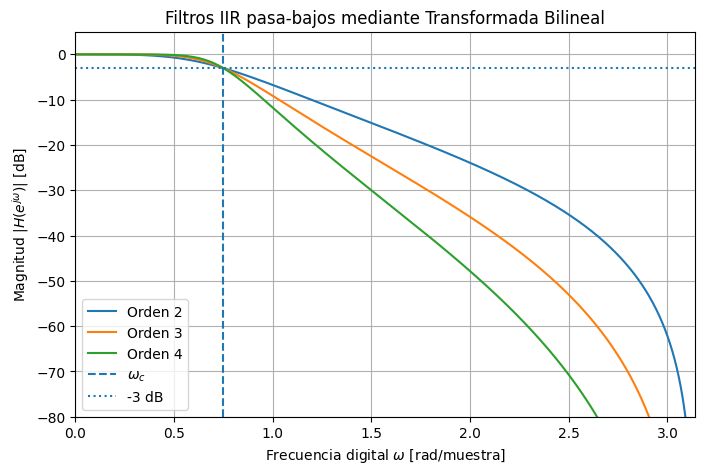

ωc = 0.7484 rad/muestra
ωc_normalizada = 0.2382 normalizada en [0 1]
ωc_experimental = 0.7486 rad/muestra
ωc_experimental_normalizada = 0.2383 normalizada en [0 1]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

fs = 8000                 # Frecuencia de muestreo [Hz]
fc = 1000                 # Frecuencia de corte filtro análogo en [Hz]
Omega_c = 2*np.pi*fc      # frecuencia de corte filtro análogo en rad/s
wc = 2*np.arctan(Omega_c/(2*fs)) # Frecuencia de corte digital en rad/muestra
ordenes = [2, 3, 4] # orden del filtro

plt.figure(figsize=(8, 5))

for N in ordenes:
    # 1. Diseño del filtro análogo Butterworth
    b_s, a_s = signal.butter(N, Omega_c, btype='low', analog=True)

    # 2. Transformada Bilineal: H(s) -> H(z)
    b_z, a_z = signal.bilinear(b_s, a_s, fs=fs)

    # 3. Respuesta en frecuencia digital
    w, H = signal.freqz(b_z, a_z, worN=2048)

    # Gráfica en dB
    H_dB = 20 * np.log10(np.abs(H) + 1e-12)
    plt.plot(w, H_dB, label=f'Orden {N}')

# Se calcula la frecuencia de corte experimental usando una de las respuestas,
# ya que todos los filtros cruzan aproximadamente en el mismo valor de ωc.
idx_wc = np.argmin(np.abs(H_dB + 3))

# Frecuencia de corte experimental
wc_exp = w[idx_wc]

plt.axvline(wc, linestyle='--', label=r'$\omega_c$')
plt.axhline(-3, linestyle=':', label='-3 dB')

plt.title('Filtros IIR pasa-bajos mediante Transformada Bilineal')
plt.xlabel(r'Frecuencia digital $\omega$ [rad/muestra]')
plt.ylabel(r'Magnitud $|H(e^{j\omega})|$ [dB]')
plt.xlim(0, np.pi); plt.ylim(-80, 5)
plt.grid(True); plt.legend(); plt.show()

print(f"ωc = {wc:.4f} rad/muestra")
print(f"ωc_normalizada = {wc/np.pi:.4f} normalizada en [0 1]")

print(f"ωc_experimental = {wc_exp:.4f} rad/muestra")
print(f"ωc_experimental_normalizada = {wc_exp/np.pi:.4f} normalizada en [0 1]")

# **Ejemplo 8.  Diseño de filtro Butterworth pasa-alto mediante Transformada Bilineal, apoyado en Python**

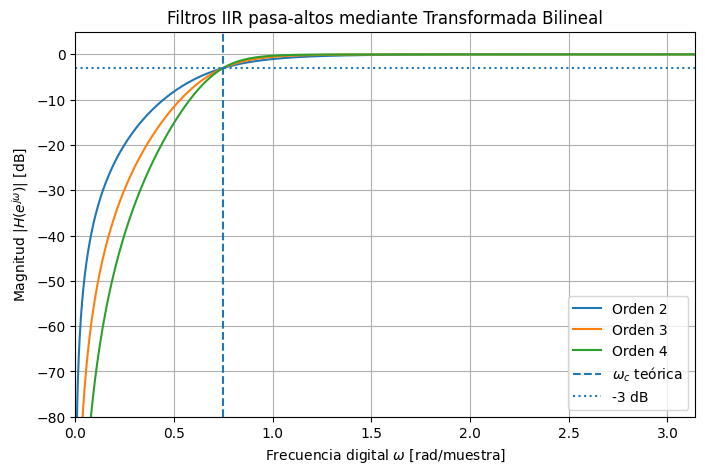

ωc teórica = 0.7484 rad/muestra
ωc teórica normalizada = 0.2382
ωc experimental = 0.7486 rad/muestra
ωc experimental normalizada = 0.2383


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Parámetros
fs = 8000                  # Frecuencia de muestreo [Hz]
fc = 1000                  # Frecuencia de corte analógica [Hz]
Omega_c = 2 * np.pi * fc   # Frecuencia de corte analógica [rad/s]

# Frecuencia de corte digital teórica (Transformada Bilineal)
wc = 2 * np.arctan(Omega_c / (2 * fs))
ordenes = [2, 3, 4] # Órdenes a comparar
plt.figure(figsize=(8, 5))

# Variables para almacenar la última respuesta
w_final = None
H_dB_final = None

for N in ordenes:

    # 1. Diseño del filtro Butterworth analógico pasa-altos
    b_s, a_s = signal.butter(N, Omega_c,
                             btype='high',
                             analog=True)

    # 2. Aplicación de la Transformada Bilineal
    b_z, a_z = signal.bilinear(b_s, a_s, fs=fs)

    # 3. Respuesta en frecuencia digital
    w, H = signal.freqz(b_z, a_z, worN=2048)

    H_dB = 20 * np.log10(np.abs(H) + 1e-12)

    plt.plot(w, H_dB, label=f'Orden {N}')

    # Guardar la respuesta del último filtro
    w_final = w
    H_dB_final = H_dB

# Frecuencia de corte experimental (-3 dB)
idx_wc = np.argmin(np.abs(H_dB_final + 3))
wc_exp = w_final[idx_wc]

# Líneas de referencia
plt.axvline(wc, linestyle='--', label=r'$\omega_c$ teórica')
plt.axhline(-3, linestyle=':', label='-3 dB')

# Configuración de la figura
plt.title('Filtros IIR pasa-altos mediante Transformada Bilineal')
plt.xlabel(r'Frecuencia digital $\omega$ [rad/muestra]')
plt.ylabel(r'Magnitud $|H(e^{j\omega})|$ [dB]')
plt.xlim(0, np.pi); plt.ylim(-80, 5)
plt.grid(True); plt.legend()
plt.show()

# Resultados
print(f"ωc teórica = {wc:.4f} rad/muestra")
print(f"ωc teórica normalizada = {wc/np.pi:.4f}")

print(f"ωc experimental = {wc_exp:.4f} rad/muestra")
print(f"ωc experimental normalizada = {wc_exp/np.pi:.4f}")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Coeficientes de H(s)
print(f"coeficientes del numerador de H(s) = {np.array2string(b_s,
                                                              precision=4, suppress_small=True)} ")
print(f"coeficientes del denominador de H(s) = {np.array2string(a_s,
                                                                precision=4, suppress_small=True)}")

# Coeficientes de H(z)
print(f"coeficientes del numerador de H(z) = {np.array2string(b_z,
                                                              precision=4, suppress_small=True)} ")
print(f"coeficientes del denominador de H(z) = {np.array2string(a_z, precision=4,
                                                                suppress_small=True)}")

coeficientes del numerador de H(s) = [1. 0. 0. 0. 0.] 
coeficientes del denominador de H(s) = [1.0000e+00 1.6419e+04 1.3479e+08 6.4819e+11 1.5585e+15]
coeficientes del numerador de H(z) = [ 0.3657 -1.4627  2.194  -1.4627  0.3657] 
coeficientes del denominador de H(z) = [ 1.     -2.0626  1.8611 -0.7931  0.1338]


Libro: Procesamiento Digital de Voz e Imágenes  en la Era de la Inteligencia Artificial

---


Versión: 2026 – Material complementario para Google Colab.